In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
jan_df = pd.read_csv('/Users/tobyzhang/Desktop/idxexchange/data/CRMLSSold202501_filled.csv')
feb_df = pd.read_csv('/Users/tobyzhang/Desktop/idxexchange/data/CRMLSSold202502.csv')
mar_df = pd.read_csv('/Users/tobyzhang/Desktop/idxexchange/data/CRMLSSold202503.csv')
apr_df = pd.read_csv('/Users/tobyzhang/Desktop/idxexchange/data/CRMLSSold202504.csv')
may_df = pd.read_csv('/Users/tobyzhang/Desktop/idxexchange/data/CRMLSSold202505.csv')

jan_df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,PasadenaFoothills,PasadenaFoothills,NaN,True,NaN,NaN,NaN,699000.0,538489291,jimo@bridgeadvisorsllc.com,...,NaN,False,NaN,NaN,90031,0.0,34350.0,NaN,False,False
1,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Carpet,Stone,Tile,Wood",True,NaN,True,True,45000.0,509724017,mwoods@marybethwoods.com,...,NaN,False,NaN,NaN,90402,NaN,5717.0,NaN,False,False
2,PalmSprings,PalmSprings,Tile,True,NaN,NaN,True,8500.0,498101084,encorepremiergroup@bdhomes.com,...,NaN,False,3.0,NaN,92270,1.0,4792.0,NaN,False,False
3,HighDesert,HighDesert,NaN,True,NaN,NaN,NaN,100000.0,446933645,billquimby.re@gmail.com,...,NaN,False,NaN,NaN,92307,NaN,217800.0,NaN,False,False
4,PalmSprings,PalmSprings,"Carpet,Tile",True,NaN,NaN,True,7500.0,441682993,encorepremiergroup@bdhomes.com,...,NaN,False,3.0,NaN,92270,1103.0,5227.0,NaN,False,False


In [5]:
# Drop 'latfilled' and 'lonfilled' from 202501 dataset

jan_df = jan_df.drop(columns=['latfilled', 'lonfilled'], errors='ignore')


In [6]:
# Ensure consistent column names and data types

jan_df.columns = jan_df.columns.str.strip()
feb_df.columns = feb_df.columns.str.strip()
mar_df.columns = mar_df.columns.str.strip()
apr_df.columns = apr_df.columns.str.strip()
may_df.columns = may_df.columns.str.strip()

In [7]:
# Combine datasets

df_combined = pd.concat([jan_df, feb_df, mar_df, apr_df, may_df], ignore_index=True)

In [8]:
# Filter for Residential and SingleFamilyResidence

df_filtered = df_combined[
    (df_combined['PropertyType'] == 'Residential') &
    (df_combined['PropertySubType'] == 'SingleFamilyResidence')
]

In [9]:
print(f"Filtered dataset shape: {df_filtered.shape}")

df_filtered.head()


Filtered dataset shape: (51262, 78)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
11,SanDiego,SanDiego,"Carpet,Tile",False,NaN,NaN,False,530000.0,1104130366,tom@structuresd.com,...,NaN,13800.0,NaN,False,0.0,NaN,92021,NaN,13800.0,NaN
12,SanDiego,SanDiego,NaN,False,NaN,NaN,False,700000.0,1104128744,chadtrower@gmail.com,...,NaN,3000.0,NaN,False,0.0,NaN,92124,170.0,3000.0,NaN
13,SanDiego,SanDiego,"Carpet,Tile",False,NaN,NaN,False,1680000.0,1104128653,lisa@premiercoastalrealty.com,...,NaN,NaN,NaN,False,2.0,NaN,92130,26.0,NaN,NaN
14,CaliforniaDesert,CaliforniaDesert,Tile,True,NaN,NaN,True,1195000.0,1104128077,lisa@traditionproperties.net,...,NaN,11761.0,NaN,False,3.0,NaN,92253,275.0,11761.0,NaN
16,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,True,NaN,NaN,NaN,3800000.0,1104126716,Djacobson.re@gmail.com,...,NaN,15365.0,NaN,False,NaN,NaN,91423,NaN,15365.0,NaN


In [10]:
features = [
    'ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
    'LotSizeAcres', 'YearBuilt', 'FireplacesTotal', 'ParkingTotal',
    'GarageSpaces', 'Stories', 'AssociationFee', 'DaysOnMarket',
    'Latitude', 'Longitude', 'City', 'CountyOrParish', 'PostalCode'
]

df_analysis = df_filtered[features].copy()


In [11]:
# Data Cleaning
# Handle missing values
missing_summary = df_analysis.isnull().sum()
print("\nMissing Values:\n", missing_summary[missing_summary > 0])


Missing Values:
 LivingArea                  29
BathroomsTotalInteger        8
LotSizeAcres               933
YearBuilt                   45
FireplacesTotal          51262
GarageSpaces              1962
Stories                   6045
AssociationFee           15050
Latitude                     4
Longitude                    4
City                        44
dtype: int64


In [12]:
print(f"Shape of df_analysis: {df_analysis.shape}")

Shape of df_analysis: (51262, 17)


In [13]:
# Convert numeric columns, handling non-numeric values
numeric_cols = [
    'ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
    'LotSizeAcres', 'YearBuilt', 'FireplacesTotal', 'ParkingTotal',
    'GarageSpaces', 'Stories', 'AssociationFee', 'DaysOnMarket',
    'Latitude', 'Longitude'
]

for col in numeric_cols:
    df_analysis[col] = df_analysis[col].replace(['N/A', 'Unknown', 'TBD', ''], np.nan)
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce', downcast='float')

In [14]:
# Fill missing numeric values with median
for col in numeric_cols:
    if df_analysis[col].isnull().sum() > 0:
        df_analysis[col].fillna(df_analysis[col].median(), inplace=True)


In [15]:
# Fill missing categorical values with mode
categorical_cols = ['City', 'CountyOrParish', 'PostalCode']
for col in categorical_cols:
    if df_analysis[col].isnull().sum() > 0:
        df_analysis[col].fillna(df_analysis[col].mode()[0], inplace=True)

In [16]:
# Remove outliers using IQR method for ClosePrice
Q1 = df_analysis['ClosePrice'].quantile(0.25)
Q3 = df_analysis['ClosePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_analysis = df_analysis[
    (df_analysis['ClosePrice'] >= lower_bound) &
    (df_analysis['ClosePrice'] <= upper_bound)
]

In [17]:
print(f"Dataset shape after outlier removal: {df_analysis.shape}")


Dataset shape after outlier removal: (47399, 17)


In [18]:
print("\nSummary Statistics:\n", df_analysis.describe())



Summary Statistics:
          ClosePrice    LivingArea  BedroomsTotal  BathroomsTotalInteger  \
count  4.739900e+04  47399.000000   47399.000000           47399.000000   
mean   9.956508e+05   1893.559326       3.405156               2.475242   
std    5.348232e+05    770.849121       0.936817               0.935712   
min    1.600000e+04      0.000000       0.000000               0.000000   
25%    6.030000e+05   1350.000000       3.000000               2.000000   
50%    8.500000e+05   1744.000000       3.000000               2.000000   
75%    1.285000e+06   2288.000000       4.000000               3.000000   
max    2.685000e+06  23727.000000      45.000000              45.000000   

       LotSizeAcres     YearBuilt  FireplacesTotal  ParkingTotal  \
count  47399.000000  47399.000000              0.0  47399.000000   
mean       6.334144   1975.465332              NaN      3.352117   
std      480.418038     27.333176              NaN     86.095573   
min        0.000000   1800.000

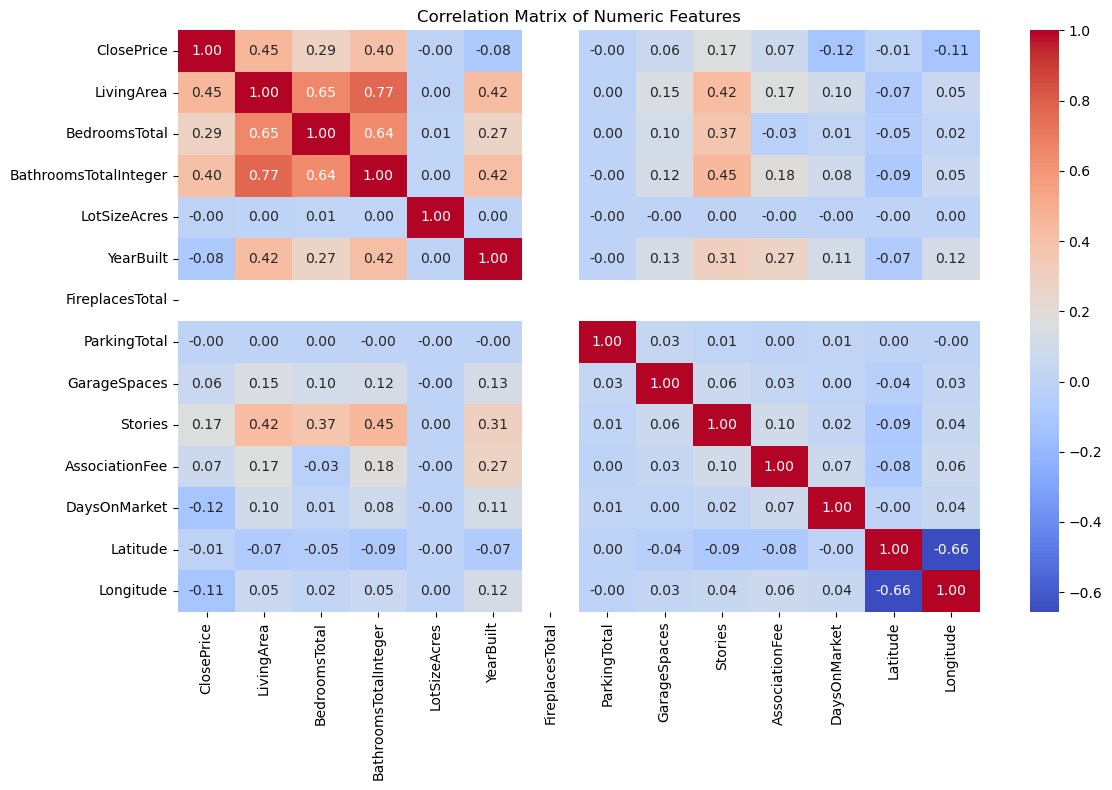

In [19]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_analysis[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

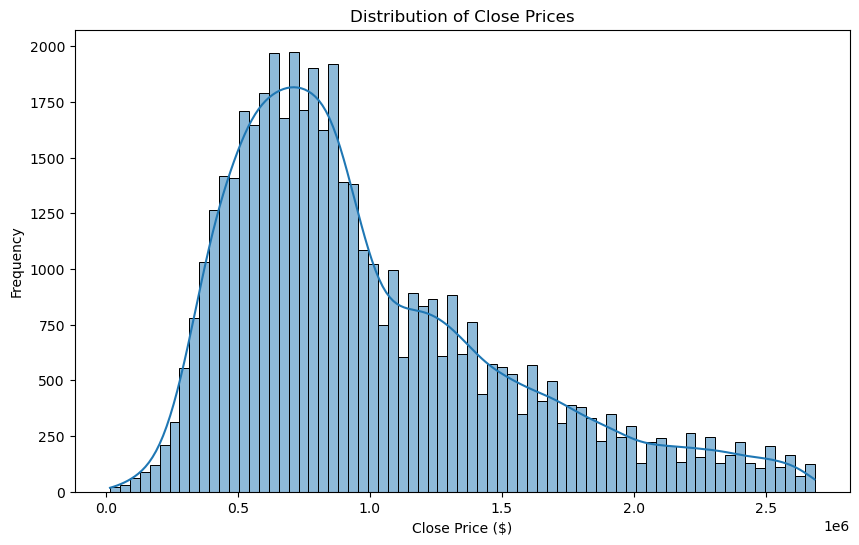

In [20]:
# Distribution of ClosePrice
plt.figure(figsize=(10, 6))
sns.histplot(df_analysis['ClosePrice'], kde=True)
plt.title('Distribution of Close Prices')
plt.xlabel('Close Price ($)')
plt.ylabel('Frequency')
plt.show()

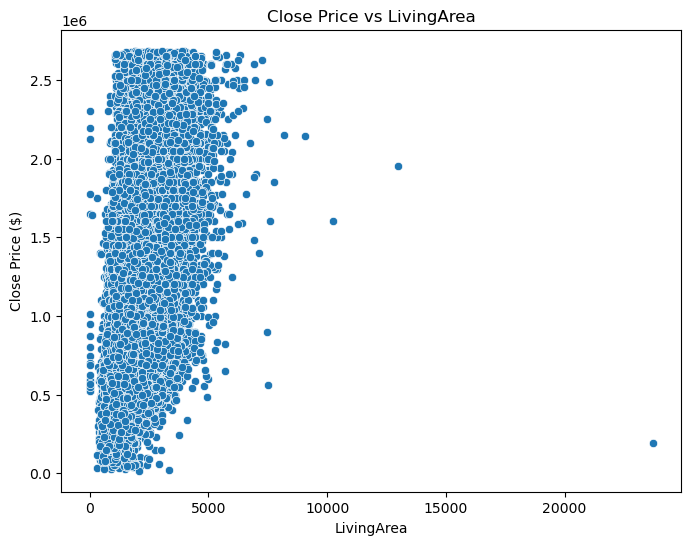

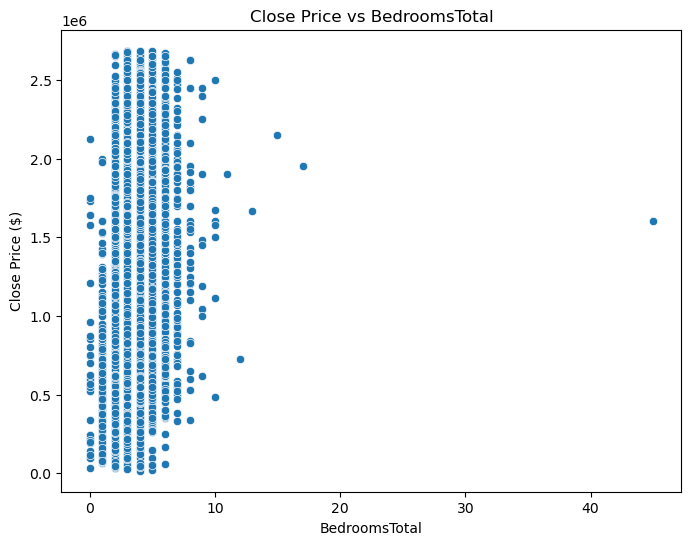

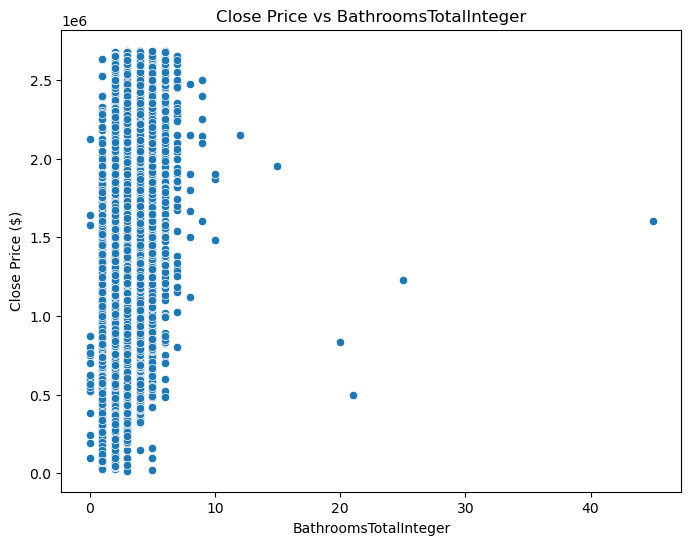

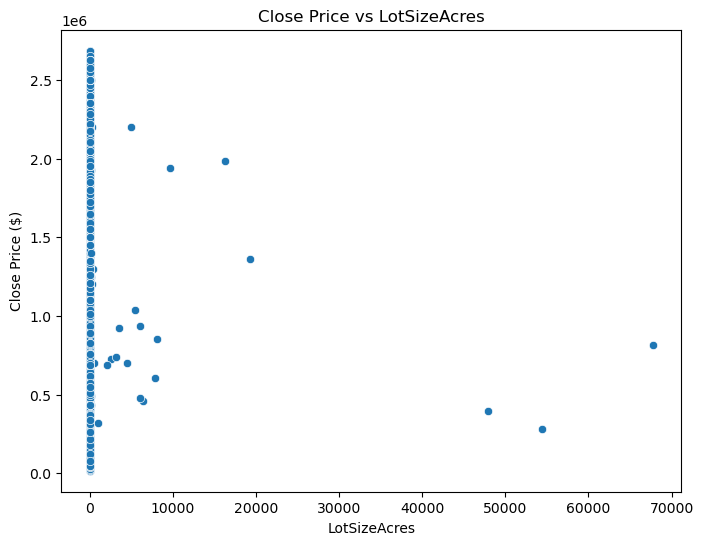

In [26]:
# Scatter plots for key features vs ClosePrice
key_features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres']
for feature in key_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df_analysis[feature], y=df_analysis['ClosePrice'])
    plt.title(f'Close Price vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Close Price ($)')
    plt.show()

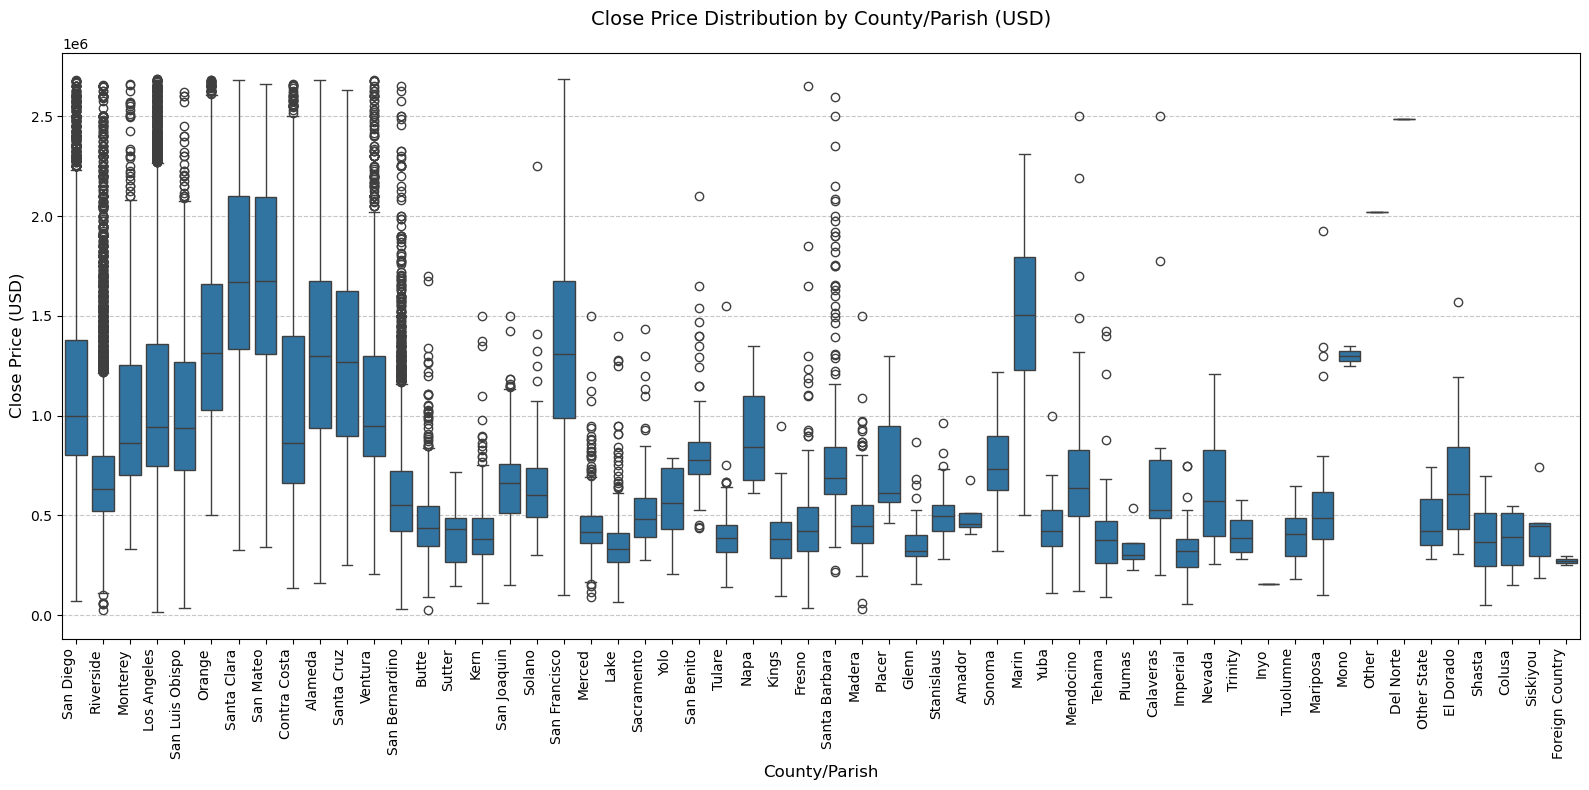

In [23]:
# Box plot for ClosePrice by CountyOrParish
plt.figure(figsize=(16, 8))  
sns.boxplot(x="CountyOrParish", y="ClosePrice", data=df_analysis)
plt.title('Close Price Distribution by County/Parish (USD)', fontsize=14, pad=20)  
plt.xlabel('County/Parish', fontsize=12) 
plt.ylabel('Close Price (USD)', fontsize=12)  
plt.xticks(rotation=90, ha='right', fontsize=10)  
plt.yticks(fontsize=10)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.tight_layout()  
plt.show()